In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

path="/content/drive/MyDrive/dataPackage/"

rfm = pd.read_csv(
    path + "rfm_modeling_snapshot.csv"
)

Mounted at /content/drive


In [3]:
rfm.shape
rfm.head()
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   object 
 1   snapshot_date             2400 non-null   object 
 2   city_tier                 2400 non-null   object 
 3   age_group                 2400 non-null   object 
 4   acquisition_channel       2400 non-null   object 
 5   loyalty_tier              1014 non-null   object 
 6   preferred_category        2400 non-null   object 
 7   marketing_consent         2400 non-null   object 
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   float64
 14  category

In [4]:
#taraget:
y = rfm['churn_next_60d']

#drop:
X = rfm.drop(
[
'customer_id',
'snapshot_date',
'churn_next_60d',
'split'
],
axis=1
)

In [5]:
categorical_cols = X.select_dtypes(
include='object'
).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(
        X[col].astype(str)
    )

In [6]:
train_df = rfm[
    rfm['split']=="train"
]

val_df = rfm[
    rfm['split']=="validation"
]

test_df = rfm[
    rfm['split']=="test"
]

In [7]:
features = [
c for c in rfm.columns
if c not in
[
'customer_id',
'snapshot_date',
'churn_next_60d',
'split'
]
]

In [8]:
X_train = X.loc[train_df.index]
y_train = y.loc[train_df.index]

X_val = X.loc[val_df.index]
y_val = y.loc[val_df.index]

X_test = X.loc[test_df.index]
y_test = y.loc[test_df.index]

In [9]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_val)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
print(
"Accuracy:",
accuracy_score(y_val, lr_pred)
)

print(
"F1:",
f1_score(y_val, lr_pred)
)

print(
"ROC AUC:",
roc_auc_score(y_val, lr_pred)
)

Accuracy: 0.8273809523809523
F1: 0.7943262411347518
ROC AUC: 0.8201058201058201


In [11]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_val
)

In [12]:
print(
"Accuracy:",
accuracy_score(y_val, rf_pred)
)

print(
"Precision:",
precision_score(y_val, rf_pred)
)

print(
"Recall:",
recall_score(y_val, rf_pred)
)

print(
"F1:",
f1_score(y_val, rf_pred)
)

print(
"ROC AUC:",
roc_auc_score(y_val, rf_pred)
)

Accuracy: 0.7976190476190477
Precision: 0.7925925925925926
Recall: 0.7278911564625851
F1: 0.7588652482269503
ROC AUC: 0.7898715041572185


In [13]:
importance = pd.DataFrame({
'feature':features,
'importance':rf_model.feature_importances_
})

importance = importance.sort_values(
'importance',
ascending=False
)

importance.head(10)

,feature,importance
6,recency_days,0.231612
24,last_visit_days_ago,0.139070
8,monetary_180d,0.089961
16,days_since_signup,0.058711
10,avg_discount_pct_180d,0.055010
18,product_views_30d,0.052895
17,sessions_30d,0.040250
7,frequency_180d,0.038487
11,avg_rating_180d,0.028597
12,category_diversity_180d,0.026838


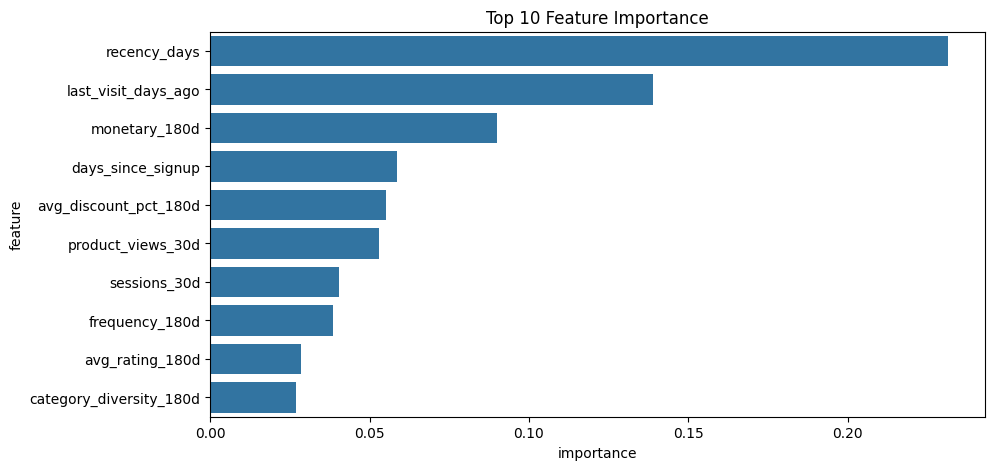

In [14]:
plt.figure(figsize=(10,5))

sns.barplot(
data=importance.head(10),
x='importance',
y='feature'
)

plt.title(
"Top 10 Feature Importance"
)

plt.show()

In [15]:
joblib.dump(
rf_model,
"model.pkl"
)

['model.pkl']

In [16]:
import json

metrics = {
"accuracy":
float(
accuracy_score(
y_val,
rf_pred
)
),

"precision":
float(
precision_score(
y_val,
rf_pred
)
),

"recall":
float(
recall_score(
y_val,
rf_pred
)
),

"f1":
float(
f1_score(
y_val,
rf_pred
)
)
}

with open(
"metrics.json",
"w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

In [18]:
from google.colab import files

files.download("model.pkl")
files.download("metrics.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>